# Post-Augmentation Validation EDA

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

plt.style.use('default')


## Загрузка данных

In [2]:
train_original = pd.read_csv(
    'train_original.csv'
)

train_augmented = pd.read_csv(
    'train_cluster_augmented.csv'
)

print('Original train:', train_original.shape)
print('Augmented train:', train_augmented.shape)


Original train: (2068, 37)
Augmented train: (6196, 39)


## Проверка synthetic rows

In [3]:
train_augmented['is_synthetic'].value_counts()

,count
is_synthetic,
1,4128
0,2068


## Проверка пропусков

In [4]:
missing = (
    train_augmented
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing


,0
house_number,1169
floor_position,1127
playground,1127
kitchen_area,69
rooms,24


## Сравнение распределений

In [5]:
compare_features = [
    'price',
    'price_per_m2',
    'area_total',
    'distance_to_center_km',
    'distance_to_mkad_km',
    'metro_distance_km',
    'latitude',
    'longitude'
]

compare_features = [
    col for col in compare_features
    if col in train_original.columns
]

compare_features


['price',
 'price_per_m2',
 'area_total',
 'distance_to_center_km',
 'distance_to_mkad_km',
 'metro_distance_km',
 'latitude',
 'longitude']

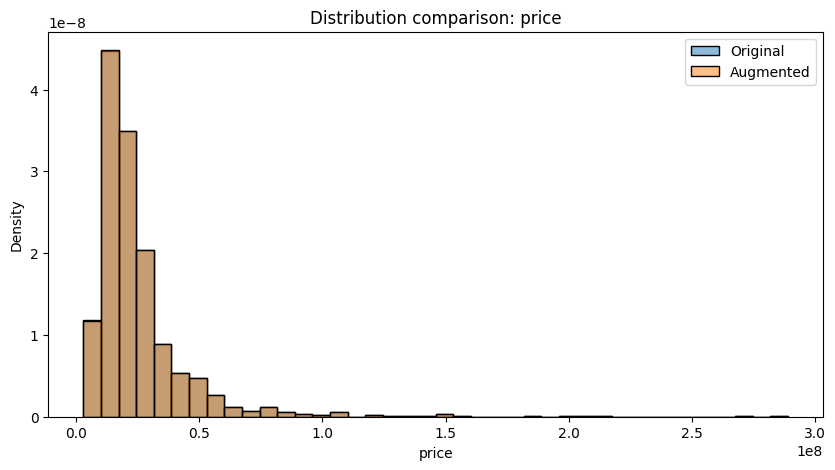

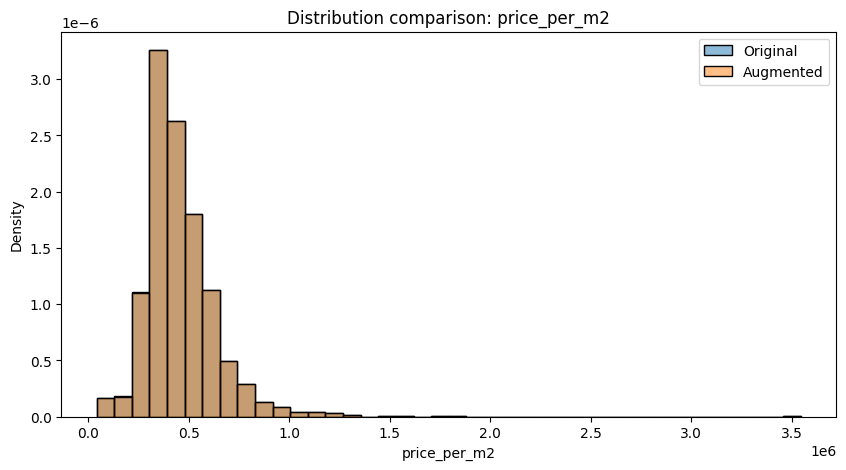

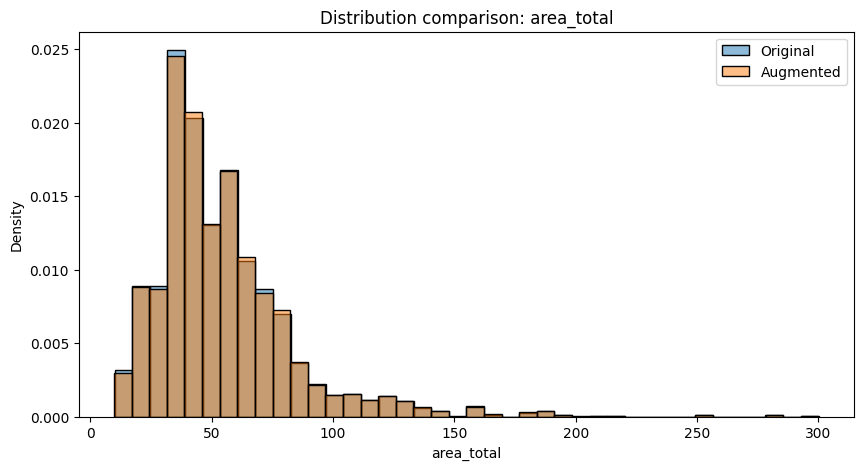

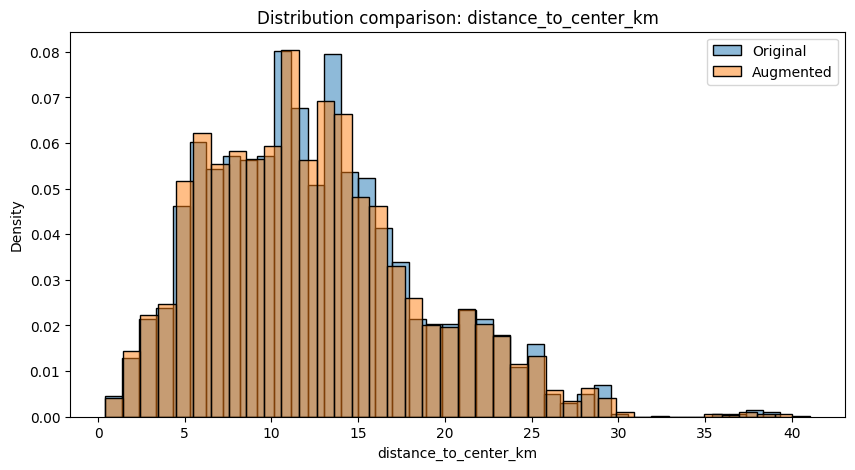

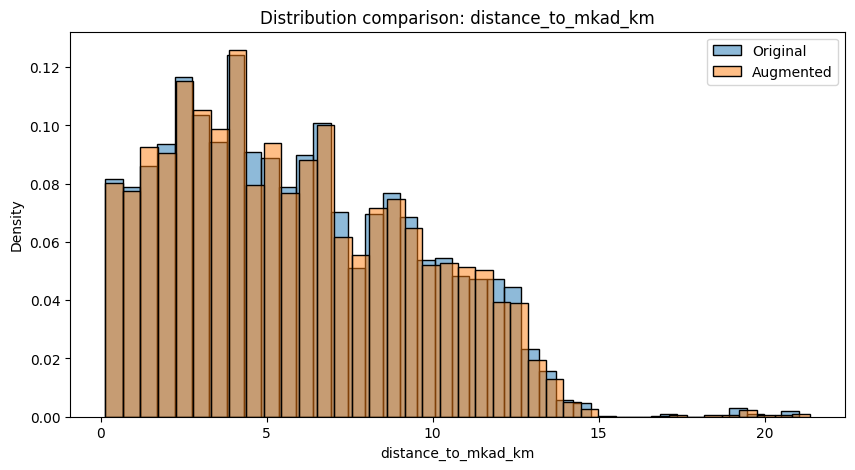

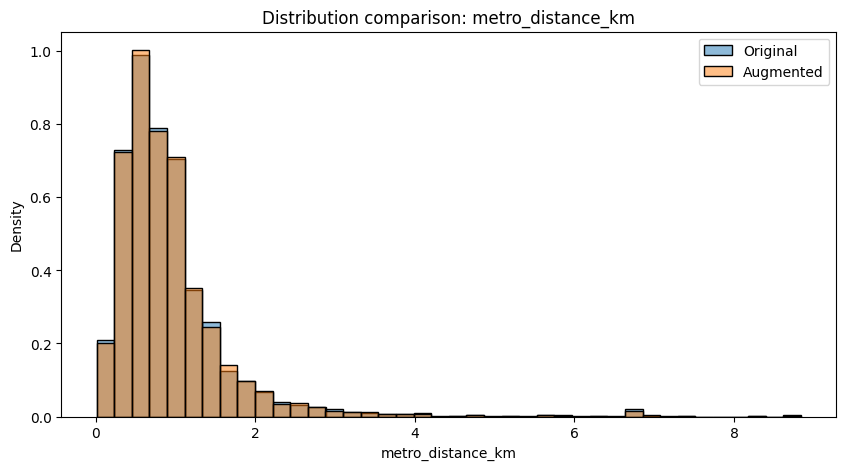

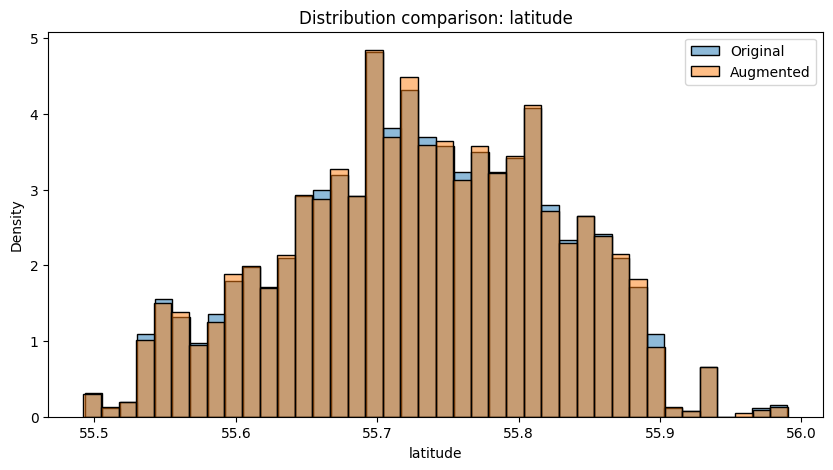

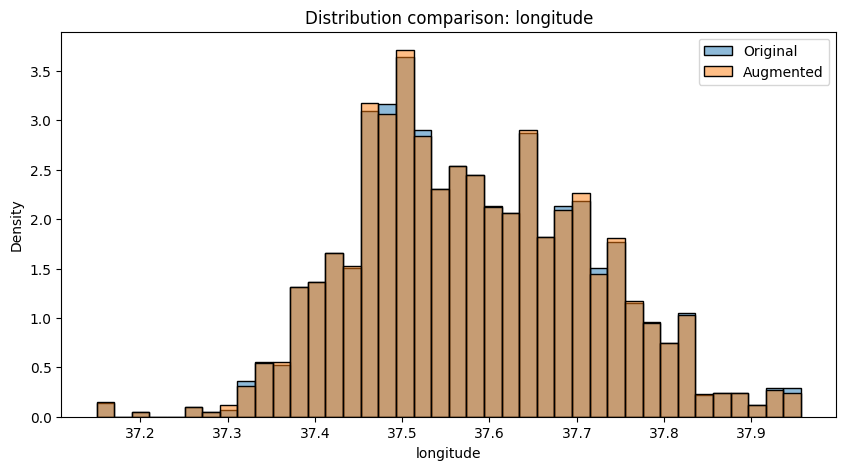

In [6]:
for feature in compare_features:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        train_original[feature],
        label='Original',
        stat='density',
        bins=40,
        alpha=0.5
    )

    sns.histplot(
        train_augmented[feature],
        label='Augmented',
        stat='density',
        bins=40,
        alpha=0.5
    )

    plt.title(f'Distribution comparison: {feature}')
    plt.legend()
    plt.show()


## Boxplots

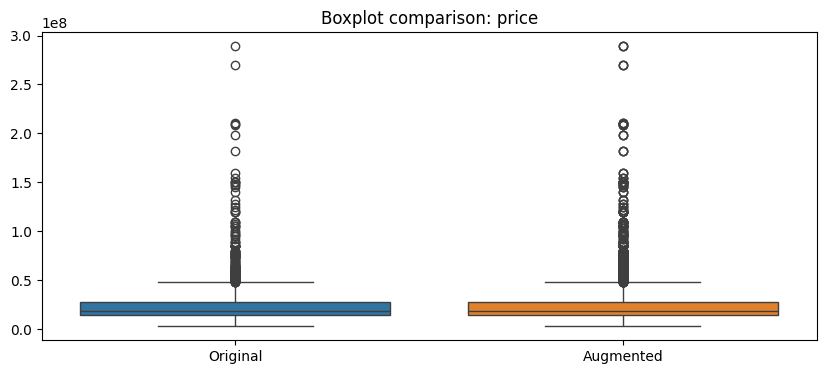

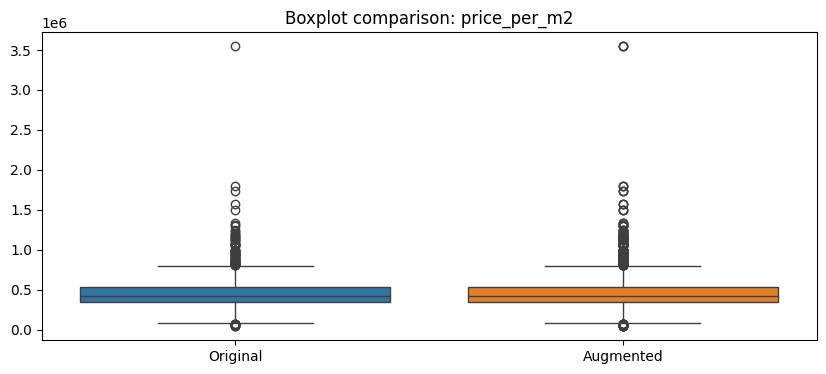

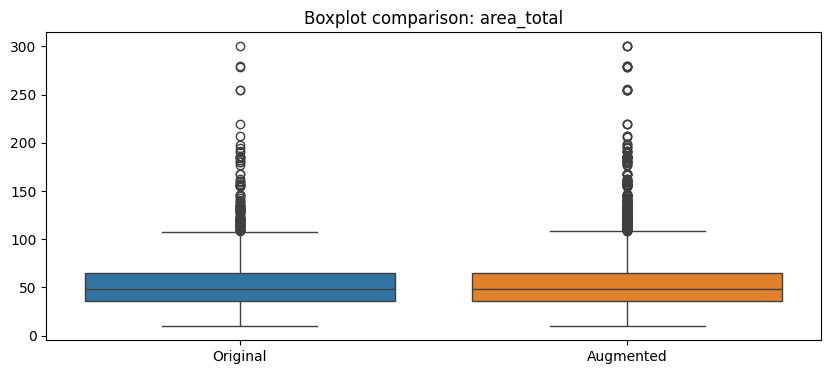

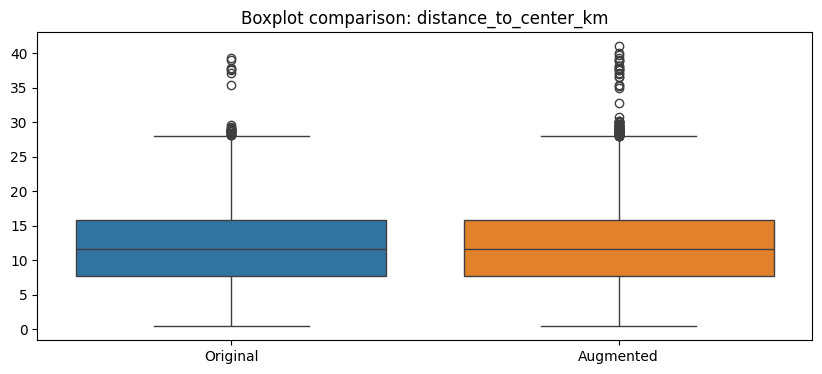

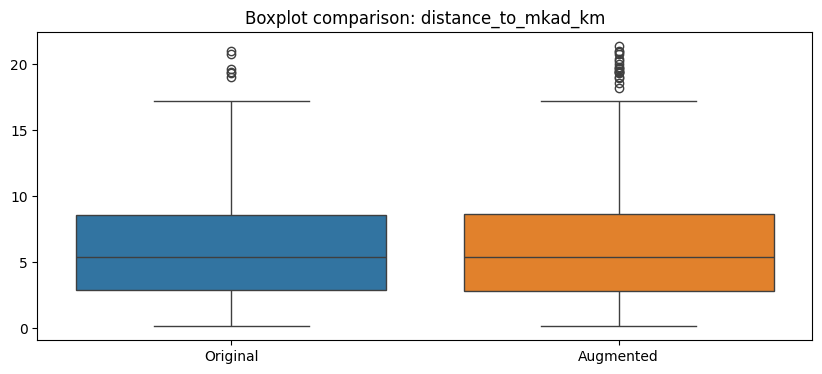

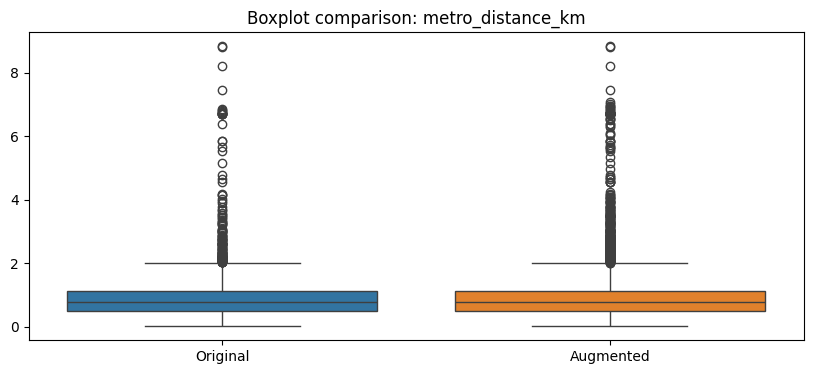

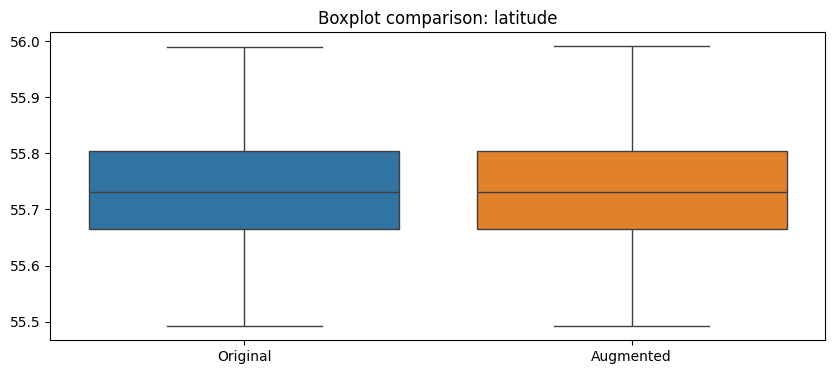

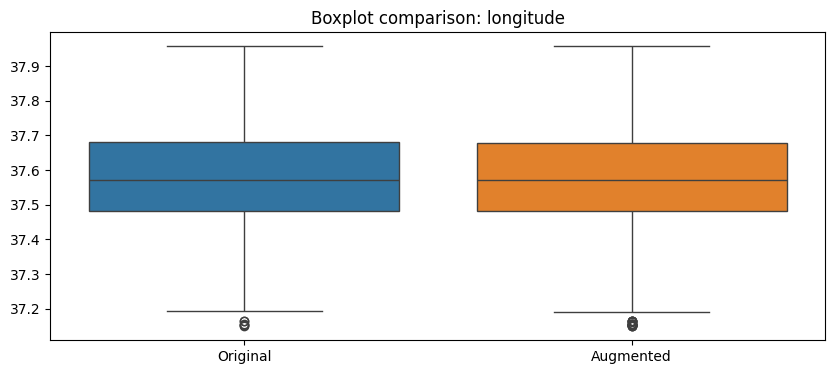

In [7]:
for feature in compare_features:

    plt.figure(figsize=(10, 4))

    data = pd.DataFrame({
        'Original': train_original[feature],
        'Augmented': train_augmented[feature]
    })

    sns.boxplot(data=data)

    plt.title(f'Boxplot comparison: {feature}')
    plt.show()


## География

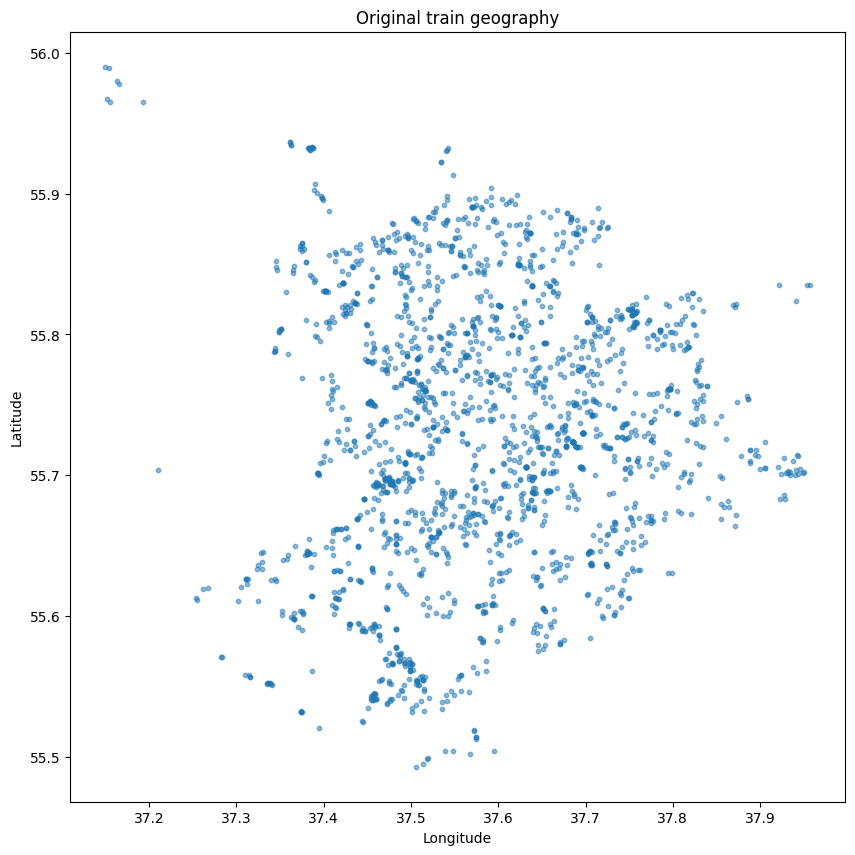

In [8]:
plt.figure(figsize=(10, 10))

plt.scatter(
    train_original['longitude'],
    train_original['latitude'],
    s=10,
    alpha=0.5
)

plt.title('Original train geography')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


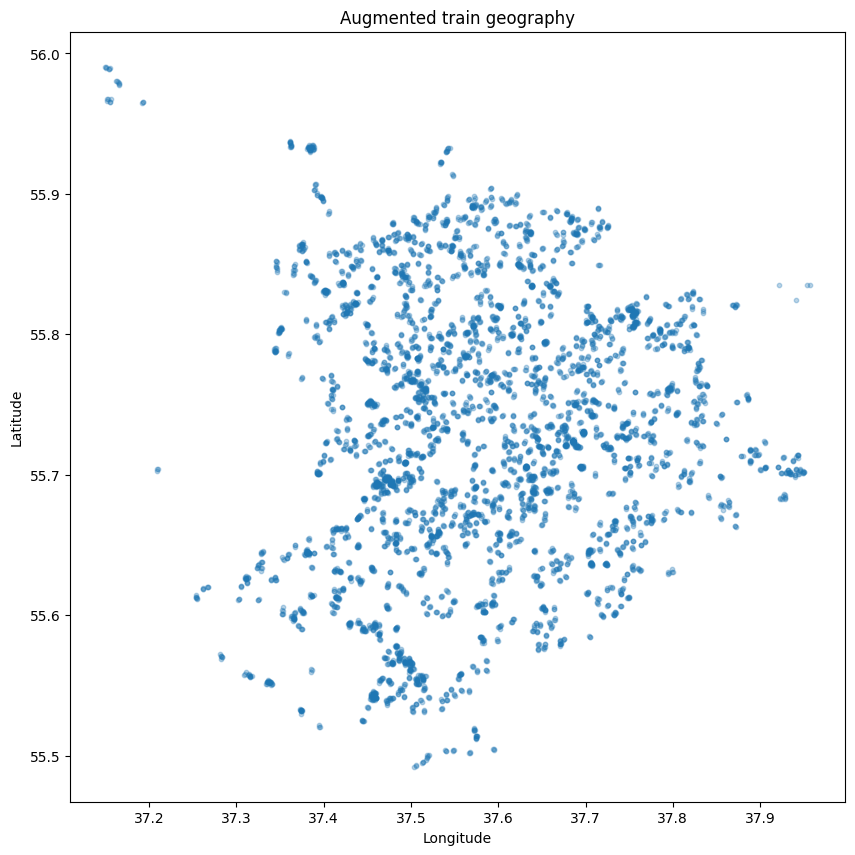

In [9]:
plt.figure(figsize=(10, 10))

plt.scatter(
    train_augmented['longitude'],
    train_augmented['latitude'],
    s=10,
    alpha=0.3
)

plt.title('Augmented train geography')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


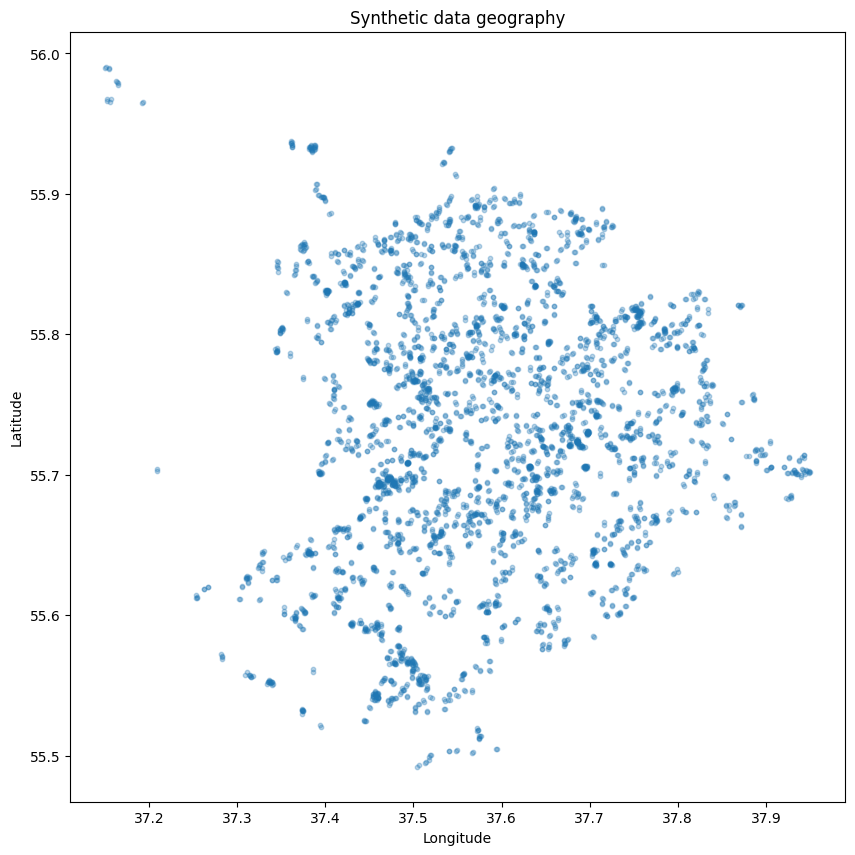

In [10]:
synthetic_only = train_augmented[
    train_augmented['is_synthetic'] == 1
]

plt.figure(figsize=(10, 10))

plt.scatter(
    synthetic_only['longitude'],
    synthetic_only['latitude'],
    s=10,
    alpha=0.3
)

plt.title('Synthetic data geography')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


## Кластеры

In [11]:
cluster_counts = (
    train_augmented['district_cluster']
    .value_counts()
    .sort_index()
)

cluster_counts


,count
district_cluster,
0,138
1,336
2,360
3,315
4,273
5,138
6,264
7,51
8,360


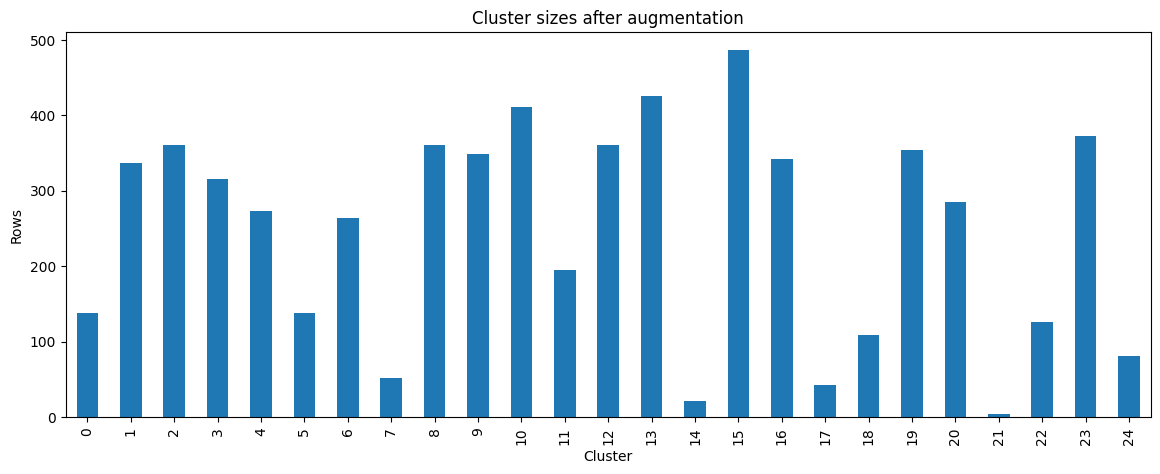

In [12]:
plt.figure(figsize=(14, 5))

cluster_counts.plot(kind='bar')

plt.title('Cluster sizes after augmentation')
plt.xlabel('Cluster')
plt.ylabel('Rows')

plt.show()


## Корреляции

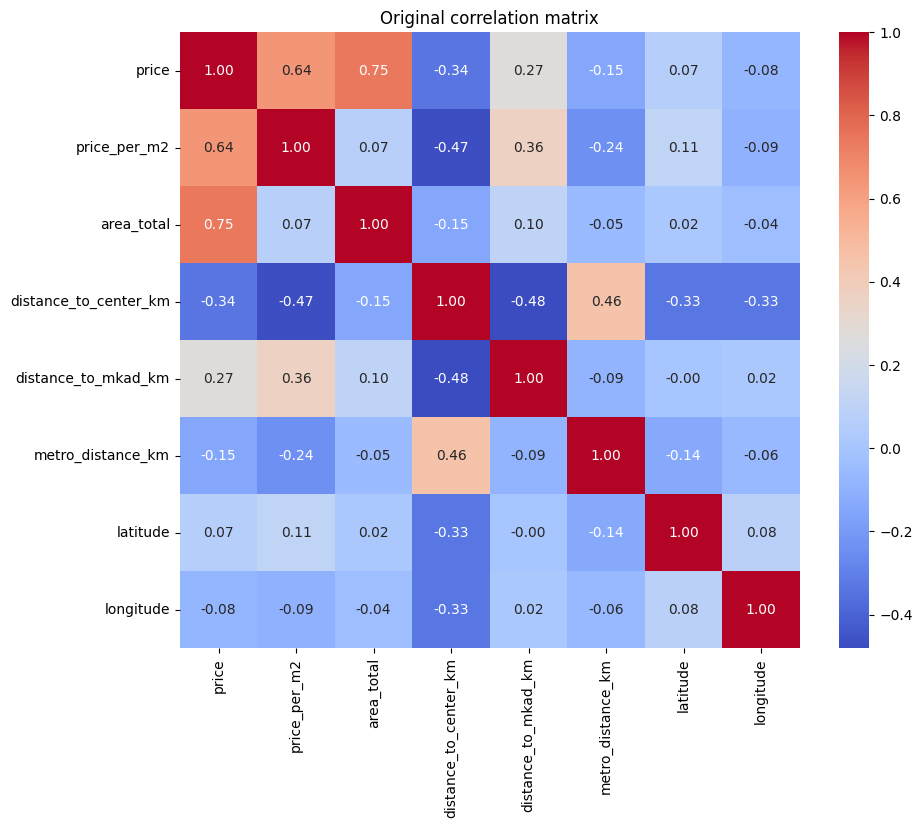

In [13]:
corr_features = [
    'price',
    'price_per_m2',
    'area_total',
    'distance_to_center_km',
    'distance_to_mkad_km',
    'metro_distance_km',
    'latitude',
    'longitude'
]

corr_features = [
    col for col in corr_features
    if col in train_original.columns
]

corr_original = (
    train_original[corr_features]
    .corr(numeric_only=True)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_original,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Original correlation matrix')
plt.show()


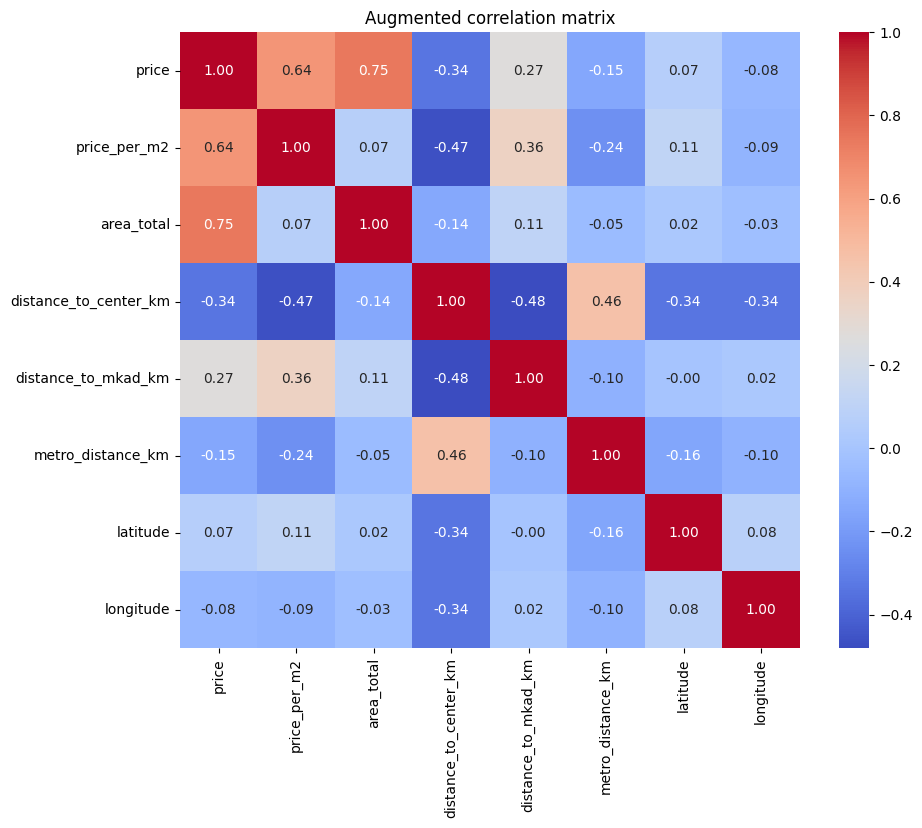

In [14]:
corr_augmented = (
    train_augmented[corr_features]
    .corr(numeric_only=True)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_augmented,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Augmented correlation matrix')
plt.show()


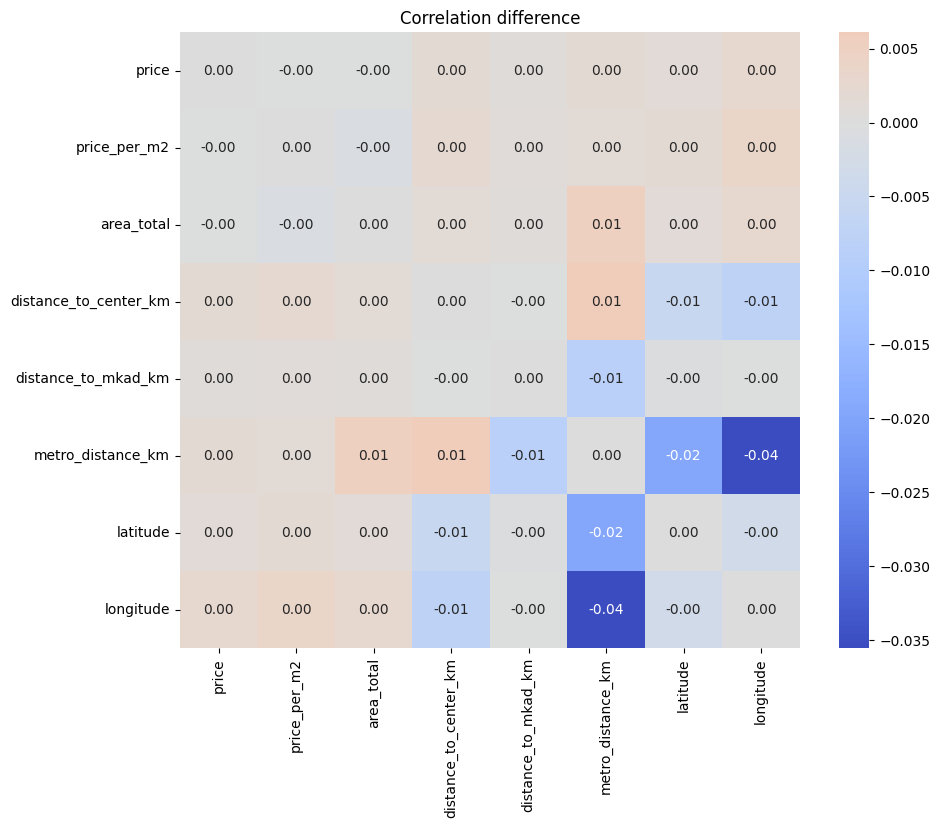

In [15]:
corr_diff = (
    corr_augmented - corr_original
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_diff,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation difference')
plt.show()


## Проверка отрицательных значений

In [16]:
numeric_cols = train_augmented.select_dtypes(
    include=np.number
).columns

negative_report = {}

for col in numeric_cols:

    negative_count = (
        train_augmented[col] < 0
    ).sum()

    if negative_count > 0:
        negative_report[col] = negative_count

negative_report


{'house_age': np.int64(33)}

## Проверка статистик

In [17]:
for feature in compare_features:

    print('\n' + '=' * 60)
    print(feature)
    print('=' * 60)

    print('\nOriginal:')
    print(train_original[feature].describe())

    print('\nAugmented:')
    print(train_augmented[feature].describe())



price

Original:
count    2.068000e+03
mean     2.527811e+07
std      2.194194e+07
min      3.000000e+06
25%      1.435000e+07
50%      1.900000e+07
75%      2.800000e+07
max      2.890000e+08
Name: price, dtype: float64

Augmented:
count    6.196000e+03
mean     2.530192e+07
std      2.194246e+07
min      3.000000e+06
25%      1.435000e+07
50%      1.900000e+07
75%      2.800000e+07
max      2.890000e+08
Name: price, dtype: float64

price_per_m2

Original:
count    2.068000e+03
mean     4.561657e+05
std      1.872567e+05
min      4.089027e+04
25%      3.474099e+05
50%      4.206623e+05
75%      5.291597e+05
max      3.546012e+06
Name: price_per_m2, dtype: float64

Augmented:
count    6.196000e+03
mean     4.564613e+05
std      1.871591e+05
min      4.089027e+04
25%      3.475893e+05
50%      4.207500e+05
75%      5.292157e+05
max      3.546012e+06
Name: price_per_m2, dtype: float64

area_total

Original:
count    2068.000000
mean       54.538588
std        29.752839
min        10.000